# Task 2 — Yelp Polarity sentiment classification (Nikhil)

Executed record of the full Member B run (RTX 5090). All logic lives in the modules next to this notebook:

| File | Contents |
|---|---|
| `prep.py` | EDA (length / class balance), missing & duplicate handling, lowercasing, punctuation & special-char removal, stopword removal (negations kept), Porter stemming, stratified train/val split, 30k vocabulary, encoding |
| `models.py` | B1 last-token baseline, B2 CNN (k=7), B3 BiLSTM + attention pooling — all with embeddings learned from scratch |
| `metrics.py` | accuracy, P/R/F1 (macro/micro/weighted), confusion matrix, ROC-AUC, PR-AUC, MCC, Brier, ECE, bootstrap CIs, McNemar, per-slice metrics |
| `train.py` | training loop, per-model timing / throughput / peak memory, comparison tables, error-review candidates |
| `configs/sentiment_nikhil_B.yaml` | every hyperparameter for this run |

Raw data: `python task2_sentiment/data/download_yelp.py` (run from repo root).

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SRC = Path.cwd()
assert (SRC / "train.py").exists(), "run this notebook from task2_sentiment/member_nikhil/src"
sys.path.insert(0, str(SRC))
import train
CONFIG = SRC / "configs" / "sentiment_nikhil_B.yaml"
print(CONFIG.read_text())

# Task 2 — Nikhil's model lineup (Two-Member Model Plan / Member B): last-token baseline, k=7 CNN, BiLSTM + attention pooling.
run_name: sentiment_nikhil_B
seed: 42
device: auto
write_metrics_report: true
log_every: 500
eval_batch_size: 512
bootstrap: 1000              # resamples for 95% CIs

data:
  raw_dir: task2_sentiment/data      # from task2_sentiment/data/download_yelp.py
  processed_dir: data_processed
  max_train_samples: null            # null = all 560k (minus dropped rows)
  max_test_samples: null             # null = all 38k
  val_frac: 0.1                      # stratified hold-out from the official train split
  vocab_size: 30000                  # incl. <pad>, <unk>
  min_freq: 2
  max_len: 256                       # tokens after cleaning; longer reviews are truncated
  stem: true                         # Porter stemming
  keep_negations: true               # keep not/no/never/but/... out of the stopword list

models:
  - name: B1_baseline_lasttoken
    arch: last_to

## Load the full run (set RUN_DIR = None to retrain everything from scratch, ~16 min on an RTX 5090)

In [2]:
RUN_DIR = SRC.parent / "outputs" / "sentiment_nikhil_B_20260929-1913"   # the committed full run
if RUN_DIR is None:
    result = train.run(CONFIG)
    out = result["out_dir"]
else:
    out = RUN_DIR
print(out.name)

sentiment_nikhil_B_20260929-1913


## Data analysis (length distribution, class balance)

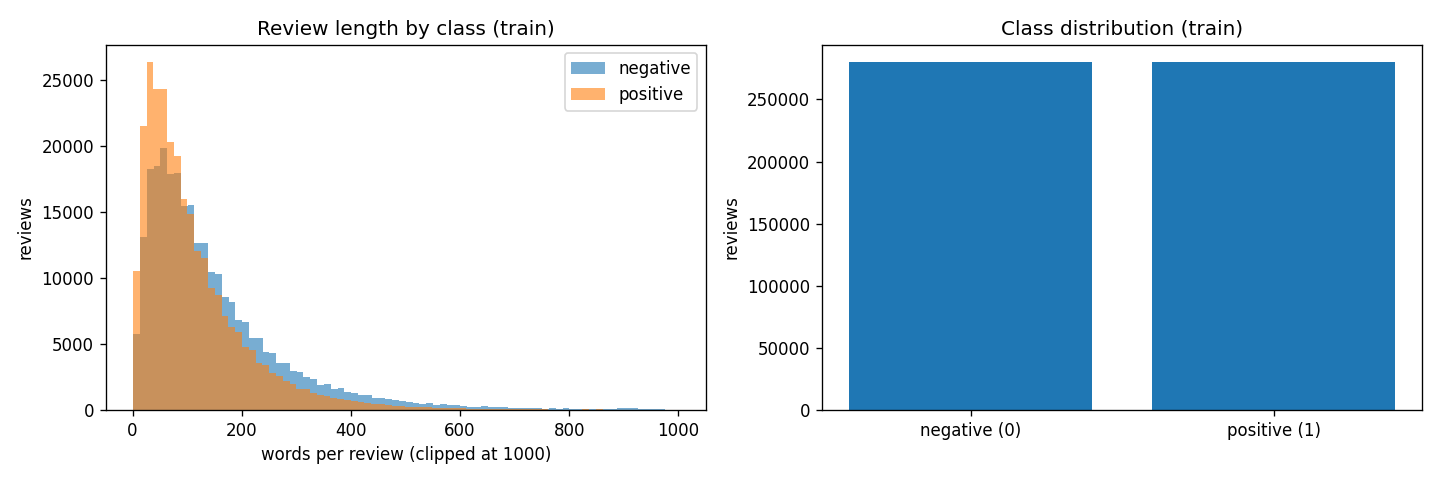

{
 "train": {
  "rows": 560000,
  "missing_text": 0,
  "empty_text": 0,
  "duplicate_text": 0,
  "class_counts": {
   "0": 280000,
   "1": 280000
  },
  "positive_share": 0.5,
  "words_mean": 133.0288732142857,
  "words_median": 97.0,
  "words_p95": 372.0,
  "words_max": 1052
 },
 "test": {
  "rows": 38000,
  "missing_text": 0,
  "empty_text": 0,
  "duplicate_text": 0,
  "class_counts": {
   "0": 19000,
   "1": 19000
  },
  "positive_share": 0.5,
  "words_mean": 132.55863157894737,
  "words_median": 97.0,
  "words_p95": 367.0,
  "words_max": 1007
 },
 "train_test_text_overlap": 0
}


In [3]:
import json
display(Image(SRC.parent / "outputs" / "eda" / "eda_length_and_class.png"))
print(json.dumps(json.loads((SRC.parent / "outputs" / "eda" / "eda_stats.json").read_text()), indent=1))

## Per-model test metrics

In [4]:
pd.set_option("display.max_columns", 80)
pd.read_csv(out / "metrics.csv").set_index("model").T

model,B1_baseline_lasttoken,B2_cnn_k7,B3_bilstm_attn
arch,last_token,cnn,bilstm_attn
parameter_count,3840129,3954945,4170497
best_epoch,6,4,8
train_time_sec,50.696616,74.43775,755.28084
train_examples_per_sec,79531.93625,54166.064861,5338.411602
peak_accelerator_mem_mb,91.5,559.0,607.1
peak_process_rss_mb,5106.3,5106.3,6077.6
hardware,NVIDIA GeForce RTX 5090,NVIDIA GeForce RTX 5090,NVIDIA GeForce RTX 5090
checkpoint,task2_sentiment\member_nikhil\checkpoints\sent...,task2_sentiment\member_nikhil\checkpoints\sent...,task2_sentiment\member_nikhil\checkpoints\sent...
val_macro_f1,0.654302,0.939262,0.951728


## Paired McNemar test (baseline vs each experiment)

In [5]:
pd.read_csv(out / "mcnemar.csv")

,baseline,experiment,b_base_right_exp_wrong,c_base_wrong_exp_right,chi2_cc,p_chi2,p_exact
0,B1_baseline_lasttoken,B2_cnn_k7,1112,12075,9112.417077,0.0,0.0
1,B1_baseline_lasttoken,B3_bilstm_attn,811,12205,9972.376229,0.0,0.0


## Robustness: macro-F1 and error rate per slice

In [6]:
pd.read_csv(out / "slice_metrics.csv").pivot_table(index=["slice", "value"], columns="model", values=["macro_f1", "error_rate"]).round(4)

error_rate                           \
model                    B1_baseline_lasttoken B2_cnn_k7 B3_bilstm_attn   
slice         value                                                       
has_contrast  False                     0.3258    0.0492         0.0398   
              True                      0.3616    0.0640         0.0512   
has_negation  False                     0.3244    0.0535         0.0444   
              True                      0.3538    0.0590         0.0469   
length_bucket len101-200                0.3566    0.0555         0.0439   
              len51-100                 0.3484    0.0567         0.0441   
              len<=50                   0.3144    0.0559         0.0487   
              len>200                   0.3673    0.0639         0.0494   

                                      macro_f1                           
model                    B1_baseline_lasttoken B2_cnn_k7 B3_bilstm_attn  
slice         value                                                      
has_contrast  False                     0.6719    0.9499         0.9595  
              True                      0.6368    0.9356         0.9485  
has_negation  False                     0.6275    0.9270         0.9398  
              True                      0.6403    0.9393         0.9517  
length_bucket len101-200                0.6425    0.9443         0.9560  
              len51-100                 0.6510    0.9430         0.9557  
              len<=50                   0.6791    0.9417         0.9492  
              len>200                   0.6227    0.9326         0.9480

## Confusion matrices, training curves, ROC and reliability

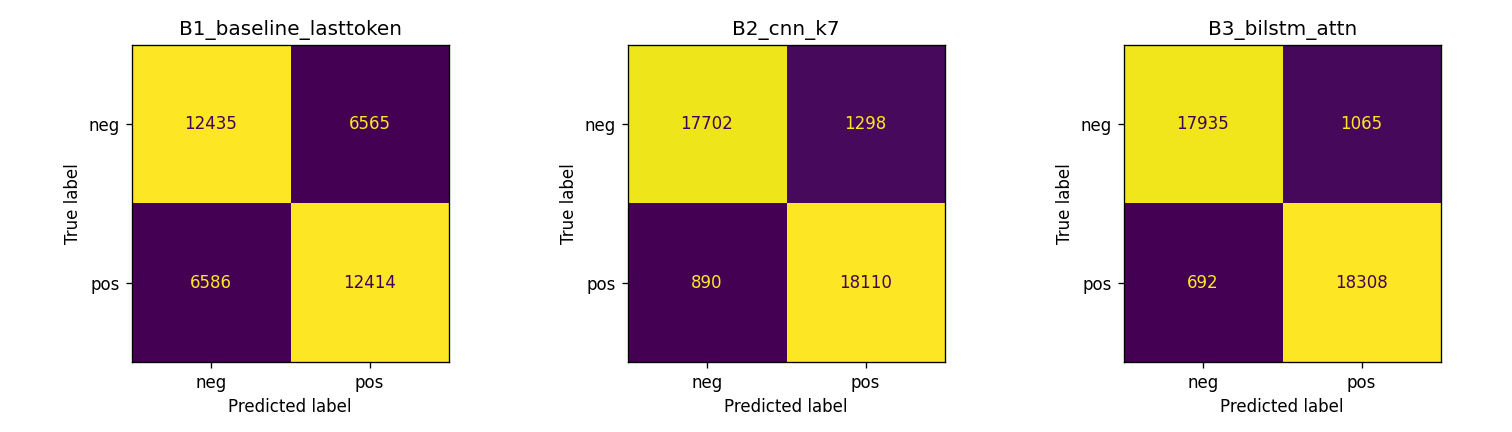

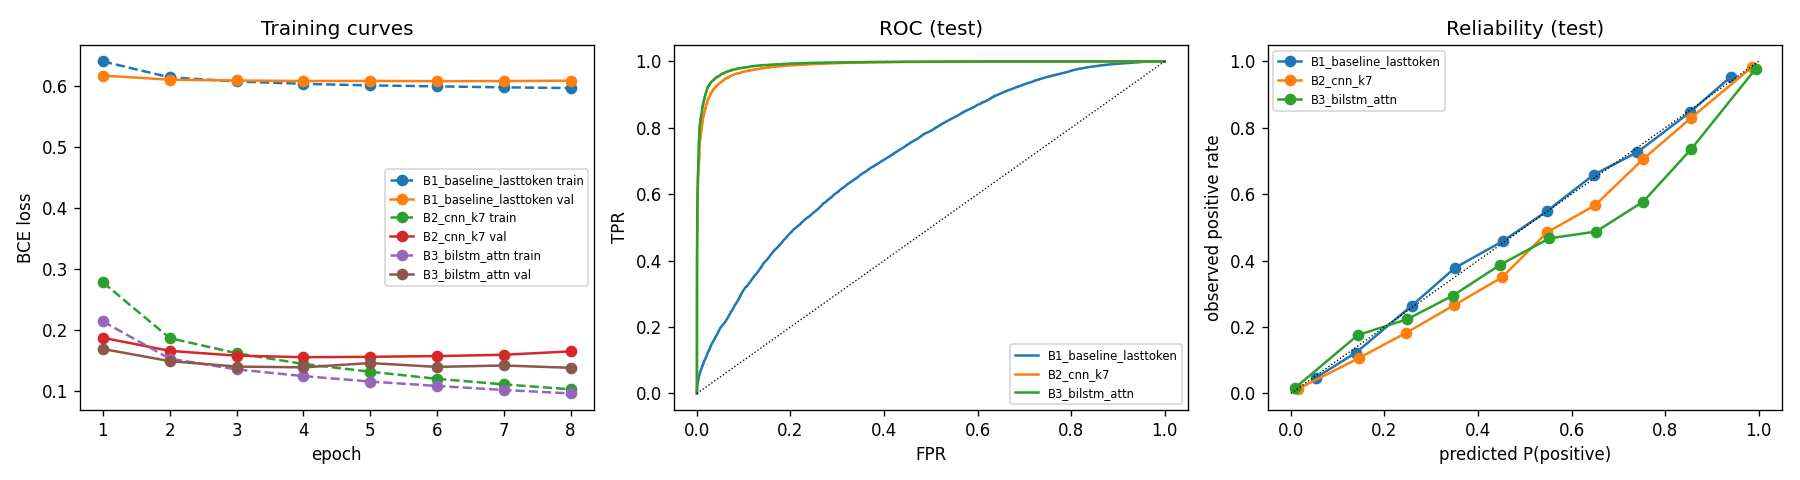

In [7]:
display(Image(out / "confusion_matrices.png"))
display(Image(out / "curves_roc_reliability.png"))

## 20 errors for manual review (strongest model)

`error_type` and `proposed_fix` are intentionally blank — fill them in by hand and write up the findings in `failure_analysis.md`.

In [8]:
pd.set_option("display.max_colwidth", 200)
pd.read_csv(next(out.glob("error_review_candidates_*.csv")))

,test_row,category,label,pred,p_pos,length_bucket,has_negation,has_contrast,text,clean,error_type,proposed_fix
0,29330,confident_false_positive,0,1,0.999977,len<=50,False,False,"Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012",wow love place veri clean new great place come relax worth tri cheer eric van nguyen visit april,NaN,NaN
1,10867,confident_false_positive,0,1,0.999874,len51-100,True,False,"One to two stars, got the Jambalaya: Marinated chicken, white rice, andouille sausage, sweet peppers and roasted green onions in a spicy traditional jambalaya sauce Wasn't: Spicy Evenly Heated ...",star got jambalaya marin chicken white rice andouil sausag sweet pepper roast green onion spici tradit jambalaya sauc not spici evenli heat delici sauc lot rice bj better jambalaya more stuff wait...,NaN,NaN
2,408,confident_false_positive,0,1,0.999824,len101-200,True,True,"Though I'm a Copper enthusiast when it comes to getting my Indian fix in Charlotte, I'd heard that Maharani was a cheaper but tasty option, so we ordered from there a few nights ago. Copper is d...",though m copper enthusiast come get indian fix charlott d heard maharani cheaper but tasti option order few night ago copper definit place but maharani fine food came veri quickli rare usual india...,NaN,NaN
3,25815,confident_false_positive,0,1,0.999777,len101-200,True,True,"Attended the @SpaFitFinder launch party, with @spacephx. I can't say much about the place, other than, even taking into consideration the number of people present, it felt cramped. The TrimTini ...",attend spafitfind launch parti spacephx ca not say place take consider number peopl present felt cramp trimtini realli delici vodkatini lemon zest veri nice gentleman work urban veri graciou make ...,NaN,NaN
4,17407,confident_false_positive,0,1,0.999626,len>200,True,True,"This was my second time dining at Company. And unfortunately, it will probably be the last. Maybe that's not fair. I'll explain. I first dined at Company back in June. My party of six was seated ...",second time dine compani unfortun probabl mayb s not fair ll explain dine compani june parti seat waiter look veri attent support server clad black pant collar shirt apron felt littl dress menu up...,NaN,NaN
5,24111,confident_false_negative,1,0,0.000503,len51-100,True,False,This review is for the pharmacy only.You do not need to be a member to use the pharmacy. I am a self paying user of generic Plavix...Cost for a 90 day supply is around is about $25. Contrast this ...,review pharmaci onli not need member use pharmaci self pay user gener plavix cost day suppli contrast walmart target shopko price differ unbeliev beg question price health insur carrier forc pay n...,NaN,NaN
6,30793,confident_false_negative,1,0,0.000517,len51-100,True,True,"This place is so much better since they changed owners. My wife and I went when it was the old owners, it was terrible. We waited forever and the food never came before we walked out. People we...",place better chang owner wife went old owner terribl wait forev food never came walk peopl serv walk wife actual got soup sat wait more horribl better staff veri friendli treat custom veri noth bu...,NaN,NaN
7,22807,confident_false_negative,1,0,0.000534,len51-100,True,True,"EDIT: They really did change the service up since I last posted this. Horrible service. Used to be my favorite pizza in the city (at a reasonable price), but I'm rethinking that. We just had an ...",edit realli did chang servic post horribl servic use favorit pizza citi reason price but m rethink just alterc server refus split check pay cash proceed disrespect parti tabl tell not attitud sorr...,NaN,NaN
8,11809,confident_false_negative,1,0,0.000577,len51-100,True,True,"Very small venue! From a time management perspective, if you are bringing your family through here, go slow at each exhibit or you will be in and out in 30 minutes. Seriously! Do not overes